## Nguyen Phuc Minh Chau - Lab02

Sinh viên thực hiện các yêu cầu sau:

- Tạo ra nhiều loại âm thanh;

- Nối các âm thanh lại;

- Sử dụng các kỹ thuật tăng cường độ biên độ âm thanh;

- Lọc âm thanh.

### Import Library

In [1]:
#Import Library
import sounddevice as sd
from scipy import signal
from IPython.display import Audio
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

### 1. Tạo ra nhiều loại âm thanh

In [10]:
sr = 22050
t = np.linspace(0, 1, sr, endpoint=False)

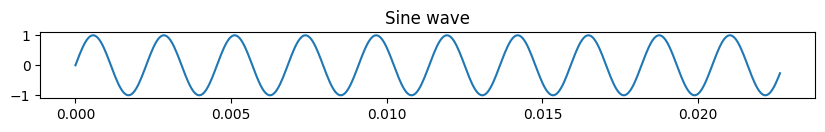

In [29]:
#Sine Wave
sine = np.sin(2 * np.pi * 440 * t)
plt.figure(figsize=(10, 6))
plt.subplot(6, 1, 1); plt.plot(t[:500], sine[:500]); plt.title('Sine wave')

sd.play(sine, samplerate=sr)
Audio(sine, rate=sr)

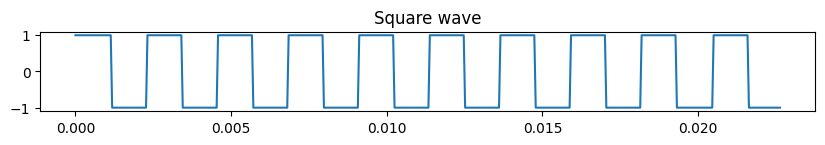

In [ ]:
#Square Wave
square = signal.square(2 * np.pi * 440 * t)
plt.figure(figsize=(10, 6))
plt.subplot(6, 1, 2); plt.plot(t[:500], square[:500]); plt.title('Square wave')

sd.play(square, samplerate=sr)
Audio(square, rate=sr)

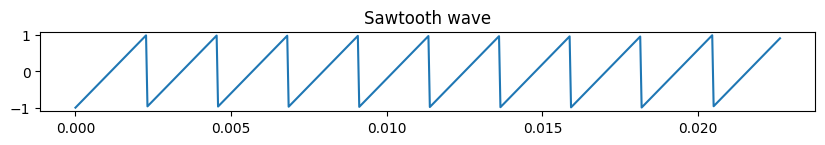

In [ ]:
#Sawtooth Wave
sawtooth = signal.sawtooth(2 * np.pi * 440 * t)
plt.figure(figsize=(10, 6))
plt.subplot(6, 1, 3); plt.plot(t[:500], sawtooth[:500]); plt.title('Sawtooth wave')

sd.play(sawtooth, samplerate=sr)
Audio(sawtooth, rate=sr)

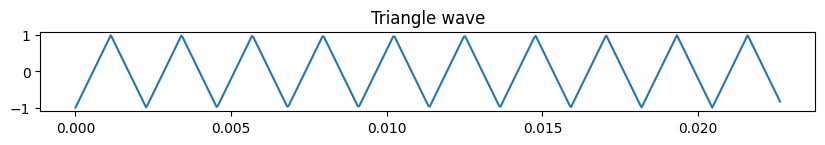

In [ ]:
#Triangle Wave
triangle = signal.sawtooth(2 * np.pi * 440 * t, 0.5)
plt.figure(figsize=(10, 6))
plt.subplot(6, 1, 4); plt.plot(t[:500], triangle[:500]); plt.title('Triangle wave')

sd.play(triangle, samplerate=sr)
Audio(triangle, rate=sr)

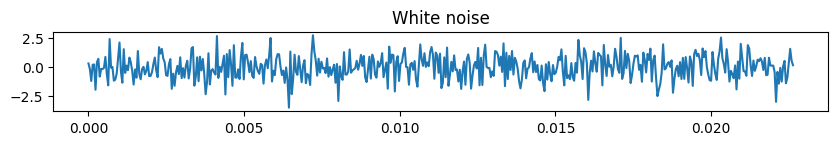

In [ ]:
noise = np.random.normal(0, 1, sr)
plt.figure(figsize=(10, 6))
plt.subplot(6, 1, 5); plt.plot(t[:500], noise[:500]); plt.title('White noise')

sd.play(noise, samplerate=sr)
Audio(noise, rate=sr)

### 2. Nối các âm thanh lại;

In [31]:
combined = np.concatenate([sine, square, sawtooth, triangle, noise])

sd.play(combined, samplerate=sr)
Audio(combined, rate=sr)

### 3. Sử dụng các kỹ thuật tăng cường độ biên độ âm thanh;

In [34]:
louder = sine * 2.0

# Normalization
normalized = sine / np.max(np.abs(sine))

louder = np.clip(louder, -1.0, 1.0)

sd.play(louder, samplerate=sr)
Audio(louder, rate=sr)

### 4. Lọc âm thanh.

In [40]:
def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

filtered = lowpass_filter(noise, cutoff=1000, fs=sr)

sd.play(filtered, samplerate=sr)
Audio(filtered, rate=sr)